# Notebook AI dự báo xu hướng bệnh nhi theo mùa vụ

Luồng đúng của notebook này:

1. **Train model** bằng dữ liệu lịch sử nhiều năm, ví dụ 2023–2025.
2. **Dự đoán** bằng dữ liệu hiện tại, ví dụ 01/2026–05/2026.
3. Output là **số ca dự đoán**, **xu hướng tăng/giảm**, **mức cảnh báo** cho tháng kế tiếp.

Phụ huynh không chạy AI trực tiếp. Phụ huynh chỉ xem kết quả đã được hệ thống dự báo và lưu lại.


In [7]:
# cell 1
# Cài thư viện cần thiết
!pip install pandas openpyxl scikit-learn joblib matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# cell 2
# Import thư viện và cấu hình file

import os
import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# CẤU HÌNH FILE
# =========================
# File train: dữ liệu lịch sử nhiều năm, ví dụ 2023-2025.
# Nếu bạn đang dùng file thật của bạn thì đặt tên đúng tại đây.
TRAIN_DATA_PATH = "train_history.xlsx"

# File dự đoán: dữ liệu hiện tại, ví dụ 01/2026-05/2026.
# Mình đã tạo file mẫu này để bạn test luồng dự đoán.
PREDICT_DATA_PATH = "predict_current.xlsx"

# Nếu để "auto", hệ thống tự lấy tháng lớn nhất trong file predict làm tháng đã chốt.
# Ví dụ file predict có dữ liệu 01/2026-05/2026 thì tháng đã chốt là 2026-05.
# Nếu file có lẫn dữ liệu tháng 6 chưa đầy đủ, hãy đặt thủ công: LAST_COMPLETED_PERIOD = "2026-05"
LAST_COMPLETED_PERIOD = "auto"

# Dự đoán bao nhiêu tháng tới?
# Bản đầu nên để 1. Có thể đổi thành 3 để dự đoán 3 tháng tới.
FORECAST_HORIZON = 1

PATIENT_SHEET = "DS-BenhNhan"
DISEASE_SHEET = "DS-MaBenh"

# Cột trong sheet DS-BenhNhan
ICD_ADMISSION_COL = "icdNV"
ICD_DISCHARGE_COL = "icdxuatvien"
CHECK_IN_DATE_COL = "check_in_date"
DATE_OF_BIRTH_COL = "date_of_birth"
GENDER_COL = "gender"

# Cột trong sheet DS-MaBenh
ICD_CODE_COL = "MAICD"
DISEASE_NAME_COL = "TENICD"
DISEASE_GROUP_COL = "TENNHOMICD"

# Dự báo theo nhóm bệnh hay bệnh cụ thể.
# Nên để "group" trước vì dữ liệu theo nhóm bệnh ổn định hơn.
PREDICT_LEVEL = "group"  # "group" hoặc "disease"

# Số cây Random Forest.
# Test nhanh: 100. Bản cuối: 300.
TOTAL_TREES = 300
STEP_TREES = 30

MODEL_DIR = Path("models")
RESULT_DIR = Path("results")

MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

print("TRAIN_DATA_PATH:", TRAIN_DATA_PATH)
print("PREDICT_DATA_PATH:", PREDICT_DATA_PATH)
print("LAST_COMPLETED_PERIOD:", LAST_COMPLETED_PERIOD)
print("FORECAST_HORIZON:", FORECAST_HORIZON)

TRAIN_DATA_PATH: train_history.xlsx
PREDICT_DATA_PATH: predict_current.xlsx
LAST_COMPLETED_PERIOD: auto
FORECAST_HORIZON: 1


In [9]:
# cell 3
# Các hàm xử lý ngày, tuổi, mùa, mã ICD

def parse_excel_date_value(x):
    """
    Xử lý ngày tháng từ Excel.
    Có trường hợp pandas đọc ra datetime.
    Có trường hợp Excel lưu ngày dưới dạng số serial.
    """
    if pd.isna(x):
        return pd.NaT

    if isinstance(x, pd.Timestamp):
        return pd.to_datetime(x)

    try:
        num = float(x)
        if 20000 <= num <= 80000:
            return pd.to_datetime("1899-12-30") + pd.to_timedelta(num, unit="D")
    except Exception:
        pass

    return pd.to_datetime(x, errors="coerce", dayfirst=True)


def parse_mixed_excel_date(series):
    return series.apply(parse_excel_date_value)


def normalize_icd(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().upper()


def calculate_age_months(check_in_date, date_of_birth):
    if pd.isna(check_in_date) or pd.isna(date_of_birth):
        return np.nan

    if check_in_date < date_of_birth:
        return np.nan

    age_months = (
        (check_in_date.year - date_of_birth.year) * 12
        + (check_in_date.month - date_of_birth.month)
        - (1 if check_in_date.day < date_of_birth.day else 0)
    )

    if age_months < 0:
        return np.nan

    return age_months


def to_age_group(age_months):
    if pd.isna(age_months):
        return "Kh?ng r?"

    if age_months < 12:
        return "D??i 1 tu?i"
    elif age_months <= 60:
        return "1-5 tu?i"
    elif age_months <= 120:
        return "6-10 tu?i"
    elif age_months <= 180:
        return "11-15 tu?i"
    else:
        return "Tr?n 15 tu?i"


def month_to_season_vn(month):
    """
    Tạm chia theo miền Nam / TP.HCM:
    - Mùa khô: tháng 12 đến tháng 4
    - Mùa mưa: tháng 5 đến tháng 11
    """
    if month in [12, 1, 2, 3, 4]:
        return "Mùa khô"
    elif month in [5, 6, 7, 8, 9, 10, 11]:
        return "Mùa mưa"
    return "Không rõ"

In [10]:
# cell 4
# Hàm kiểm tra file và đọc bảng mã bệnh DS-MaBenh

def ensure_file_exists(file_path):
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file: {file_path}\n"
            f"Hãy đặt file cùng thư mục notebook hoặc sửa lại đường dẫn trong Cell 2."
        )


def load_disease_codes_from_excel(file_path):
    ensure_file_exists(file_path)

    disease_codes = pd.read_excel(file_path, sheet_name=DISEASE_SHEET)

    required_cols = [ICD_CODE_COL, DISEASE_NAME_COL, DISEASE_GROUP_COL]
    missing_cols = [c for c in required_cols if c not in disease_codes.columns]

    if missing_cols:
        raise ValueError(f"Sheet {DISEASE_SHEET} thiếu cột: {missing_cols}")

    disease_codes[ICD_CODE_COL] = disease_codes[ICD_CODE_COL].apply(normalize_icd)

    print("Đã đọc bảng mã bệnh từ:", file_path)
    print("Số dòng DS-MaBenh:", len(disease_codes))

    return disease_codes

In [11]:
# cell 5
# Hàm đọc và xử lý sheet DS-BenhNhan

def load_patients_from_excel(file_path, disease_codes):
    ensure_file_exists(file_path)

    patients = pd.read_excel(file_path, sheet_name=PATIENT_SHEET)

    print("\n==============================")
    print("Đọc file:", file_path)
    print("Số dòng bệnh nhân ban đầu:", len(patients))
    print("==============================")

    required_cols = [
        ICD_ADMISSION_COL,
        ICD_DISCHARGE_COL,
        CHECK_IN_DATE_COL,
        DATE_OF_BIRTH_COL,
        GENDER_COL
    ]

    missing_cols = [c for c in required_cols if c not in patients.columns]

    if missing_cols:
        raise ValueError(f"Sheet {PATIENT_SHEET} thiếu cột: {missing_cols}")

    # Xử lý ngày
    patients[CHECK_IN_DATE_COL] = parse_mixed_excel_date(patients[CHECK_IN_DATE_COL])
    patients[DATE_OF_BIRTH_COL] = parse_mixed_excel_date(patients[DATE_OF_BIRTH_COL])

    # Chuẩn hóa mã ICD
    patients[ICD_ADMISSION_COL] = patients[ICD_ADMISSION_COL].apply(normalize_icd)
    patients[ICD_DISCHARGE_COL] = patients[ICD_DISCHARGE_COL].apply(normalize_icd)

    # Ưu tiên mã xuất viện, nếu trống thì lấy mã nhập viện
    patients["main_icd"] = patients[ICD_DISCHARGE_COL].fillna(patients[ICD_ADMISSION_COL])
    patients["main_icd"] = patients["main_icd"].apply(normalize_icd)

    # Nối mã ICD với tên bệnh/nhóm bệnh
    df = patients.merge(
        disease_codes,
        left_on="main_icd",
        right_on=ICD_CODE_COL,
        how="left"
    )

    # Tính tuổi
    # T?nh tu?i th?ng ch?nh x?c, r?i quy ??i sang tu?i n?m ?? hi?n th? n?u c?n
    df["age_months"] = df.apply(
        lambda row: calculate_age_months(row[CHECK_IN_DATE_COL], row[DATE_OF_BIRTH_COL]),
        axis=1
    )

    df["age"] = df["age_months"] / 12.0
    df["age_group"] = df["age_months"].apply(to_age_group)
    df["year"] = df[CHECK_IN_DATE_COL].dt.year
    df["month_num"] = df[CHECK_IN_DATE_COL].dt.month
    df["period"] = df[CHECK_IN_DATE_COL].dt.to_period("M").astype(str)
    df["season"] = df["month_num"].apply(month_to_season_vn)

    # Tên bệnh / nhóm bệnh
    df["disease_name"] = df[DISEASE_NAME_COL].fillna("Không rõ bệnh")
    df["disease_group"] = df[DISEASE_GROUP_COL].fillna("Không rõ nhóm bệnh")

    # Giới tính
    df[GENDER_COL] = df[GENDER_COL].fillna("Không rõ").astype(str).str.strip()

    # Bỏ dòng không có ngày khám hoặc không có mã bệnh
    df = df.dropna(subset=[CHECK_IN_DATE_COL, "main_icd"])

    print("Số dòng sau xử lý:", len(df))

    if len(df) > 0:
        print("Dữ liệu từ tháng:", df["period"].min())
        print("Dữ liệu đến tháng:", df["period"].max())
        print("Số mã ICD không nối được tên bệnh:", int((df["disease_name"] == "Không rõ bệnh").sum()))

    return df

In [12]:
# cell 6
# Load dữ liệu train lịch sử và dữ liệu hiện tại để dự đoán

# Lấy bảng mã bệnh từ file train
disease_codes = load_disease_codes_from_excel(TRAIN_DATA_PATH)

# Dữ liệu lịch sử để train, ví dụ 2023-2025
train_df = load_patients_from_excel(TRAIN_DATA_PATH, disease_codes)

# Dữ liệu hiện tại để dự đoán, ví dụ 01/2026-05/2026
predict_df = load_patients_from_excel(PREDICT_DATA_PATH, disease_codes)

print("\n===== KIỂM TRA DỮ LIỆU =====")
print("Dữ liệu TRAIN:", train_df["period"].min(), "→", train_df["period"].max())
print("Dữ liệu PREDICT:", predict_df["period"].min(), "→", predict_df["period"].max())

display(train_df.head())
display(predict_df.head())

Đã đọc bảng mã bệnh từ: train_history.xlsx
Số dòng DS-MaBenh: 12230

Đọc file: train_history.xlsx
Số dòng bệnh nhân ban đầu: 257771
Số dòng sau xử lý: 257771
Dữ liệu từ tháng: 2021-01
Dữ liệu đến tháng: 2025-04
Số mã ICD không nối được tên bệnh: 3

Đọc file: predict_current.xlsx
Số dòng bệnh nhân ban đầu: 16332
Số dòng sau xử lý: 16332
Dữ liệu từ tháng: 2022-01
Dữ liệu đến tháng: 2026-05
Số mã ICD không nối được tên bệnh: 254

===== KIỂM TRA DỮ LIỆU =====
Dữ liệu TRAIN: 2021-01 → 2025-04
Dữ liệu PREDICT: 2022-01 → 2026-05


,icdNV,icdxuatvien,check_in_date,date_of_birth,month,gender,main_icd,MAICD,TENICD,IDNHOMICD,...,MANHOMBAOCAO,TENTIENGANH,age,age_group,year,month_num,period,season,disease_name,disease_group
0,K21,K21,2025-04-26 12:47:00,2025-03-21,1.0,Nữ,K21,K21,Bệnh trào ngược dạ dày - thực quản,185.0,...,"K20-K23,K28,K30-K31",Gastro-oesophageal reflux disease,0.098563,Dưới 1 tuổi,2025,4,2025-04,Mùa khô,Bệnh trào ngược dạ dày - thực quản,"Bệnh khác của thực quản, dạ dày và tá tràng - ..."
1,T78.4,L50.0,2025-04-26 12:25:00,2024-04-26,12.0,Nữ,L50.0,L50.0,Mày đay dị ứng,199.0,...,L10-L99,Allergic urticaria,0.999316,Dưới 1 tuổi,2025,4,2025-04,Mùa khô,Mày đay dị ứng,Bệnh khác của da và mô tế bào dưới da - Other ...
2,K12,B08.4,2025-04-26 10:54:00,2023-11-09,17.0,Nam,B08.4,B08.4,Viêm họng có phỏng nước do virus đường ruột vớ...,41.0,...,"A81,A87-A89,B03-B04,B07-B09,B25,B27-B34",Enteroviral vesicular stomatitis with exanthem,1.462012,1-5 tuổi,2025,4,2025-04,Mùa khô,Viêm họng có phỏng nước do virus đường ruột vớ...,Bệnh virut khác - Other viral diseases
3,J02,A09.9,2025-04-26 10:38:00,2021-08-16,44.0,Nam,A09.9,A09.9,Viêm dạ dày - ruột và viêm đại tràng khác khôn...,5.0,...,A09,Gastroenteritis and colitis of unspecified origin,3.693361,1-5 tuổi,2025,4,2025-04,Mùa khô,Viêm dạ dày - ruột và viêm đại tràng khác khôn...,"Ỉa chảy, viêm dạy dày, ruột non có nguồn gốc n..."
4,S52.4,S52,2025-04-26 09:19:00,2012-04-25,156.0,Nữ,S52,S52,Gẫy xương ở cẳng tay,274.0,...,"S42,S52,S62,S82,S92,T10,T12",Fracture of forearm,13.002053,11-15 tuổi,2025,4,2025-04,Mùa khô,Gẫy xương ở cẳng tay,Gãy các phần khác của chi do lao động và giao ...


,icdNV,icdxuatvien,check_in_date,date_of_birth,month,gender,main_icd,MAICD,TENICD,IDNHOMICD,...,MANHOMBAOCAO,TENTIENGANH,age,age_group,year,month_num,period,season,disease_name,disease_group
0,J18,J18,2022-01-20 23:16:00,2020-07-26 23:16:00,1,Nam,J18,J18,"Viêm phổi, tác nhân không xác định",169.0,...,J12-J18,"Pneumonia, organism unspecified",1.486653,1-5 tuổi,2022,1,2022-01,Mùa khô,"Viêm phổi, tác nhân không xác định",Các bệnh viêm phổi - Pneumonia
1,G40.5,G40.5,2022-01-24 18:35:00,2010-01-29 18:35:00,1,Nữ,G40.5,G40.5,Hội chứng động kinh đặc hiệu,124.0,...,G40-G41,Special epileptic syndromes,11.986311,11-15 tuổi,2022,1,2022-01,Mùa khô,Hội chứng động kinh đặc hiệu,Động kinh - Epilepsy
2,R50,J20,2022-01-12 14:15:00,2021-04-05 14:15:00,1,Nam,J20,J20,Viêm phế quản cấp,170.0,...,J20-J21,Acute bronchitis,0.772074,Dưới 1 tuổi,2022,1,2022-01,Mùa khô,Viêm phế quản cấp,Viêm phế quản và viêm tiểu phế quản cấp - Acut...
3,K52.9,K52.9,2022-01-27 01:56:00,2021-06-13 01:56:00,1,Nam,K52.9,K52.9,Viêm dạ dày - ruột và đại tràng không nhiễm tr...,192.0,...,"K52-K55,K58-K67","Noninfective gastroenteritis and colitis, unsp...",0.624230,Dưới 1 tuổi,2022,1,2022-01,Mùa khô,Viêm dạ dày - ruột và đại tràng không nhiễm tr...,Bệnh khác của ruột non và màng bụng - Other di...
4,J20,J20,2022-01-19 17:17:00,2021-04-28 17:17:00,1,Nam,J20,J20,Viêm phế quản cấp,170.0,...,J20-J21,Acute bronchitis,0.728268,Dưới 1 tuổi,2022,1,2022-01,Mùa khô,Viêm phế quản cấp,Viêm phế quản và viêm tiểu phế quản cấp - Acut...


In [13]:
# cell 7
# Gom dữ liệu bệnh nhân thành số ca theo tháng

def create_monthly_stats(df):
    if PREDICT_LEVEL == "group":
        target_col = "disease_group"
    else:
        target_col = "disease_name"

    monthly_stats = (
        df.groupby(["period", "year", "month_num", "season", target_col, "age_group"])
          .size()
          .reset_index(name="case_count")
    )

    monthly_stats = monthly_stats.rename(columns={target_col: "disease_target"})

    return monthly_stats


train_monthly = create_monthly_stats(train_df)
predict_monthly = create_monthly_stats(predict_df)

print("Số dòng thống kê tháng của dữ liệu TRAIN:", len(train_monthly))
print("Số dòng thống kê tháng của dữ liệu PREDICT:", len(predict_monthly))

display(train_monthly.head(20))
display(predict_monthly.head(20))

Số dòng thống kê tháng của dữ liệu TRAIN: 19429
Số dòng thống kê tháng của dữ liệu PREDICT: 2925


,period,year,month_num,season,disease_target,age_group,case_count
0,2021-01,2021,1,Mùa khô,Bệnh bạch cầu - Leukaemia,1-5 tuổi,2
1,2021-01,2021,1,Mùa khô,Bệnh bạch cầu - Leukaemia,6-10 tuổi,1
2,2021-01,2021,1,Mùa khô,Bệnh cầu thận khác - Other glomerular diseases,11-15 tuổi,1
3,2021-01,2021,1,Mùa khô,Bệnh cầu thận khác - Other glomerular diseases,6-10 tuổi,1
4,2021-01,2021,1,Mùa khô,Bệnh của hệ thống tổ chức liên kết - Systemati...,1-5 tuổi,2
5,2021-01,2021,1,Mùa khô,Bệnh của mũi và các xoang phụ của mũi - Other ...,Dưới 1 tuổi,1
6,2021-01,2021,1,Mùa khô,Bệnh khác của bộ máy tiêu hoá - Other diseases...,1-5 tuổi,5
7,2021-01,2021,1,Mùa khô,Bệnh khác của bộ máy tiết niệu - Other disease...,1-5 tuổi,2
8,2021-01,2021,1,Mùa khô,Bệnh khác của bộ máy tiết niệu - Other disease...,6-10 tuổi,1
9,2021-01,2021,1,Mùa khô,Bệnh khác của bộ máy tiết niệu - Other disease...,Dưới 1 tuổi,1


,period,year,month_num,season,disease_target,age_group,case_count
0,2022-01,2022,1,Mùa khô,Bệnh khác của ruột non và màng bụng - Other di...,1-5 tuổi,6
1,2022-01,2022,1,Mùa khô,Bệnh khác của ruột non và màng bụng - Other di...,6-10 tuổi,4
2,2022-01,2022,1,Mùa khô,Bệnh khác của ruột non và màng bụng - Other di...,Dưới 1 tuổi,2
3,2022-01,2022,1,Mùa khô,"Bệnh khác của thực quản, dạ dày và tá tràng - ...",1-5 tuổi,1
4,2022-01,2022,1,Mùa khô,"Bệnh khác của thực quản, dạ dày và tá tràng - ...",11-15 tuổi,5
5,2022-01,2022,1,Mùa khô,"Bệnh khác của thực quản, dạ dày và tá tràng - ...",6-10 tuổi,3
6,2022-01,2022,1,Mùa khô,Bệnh virut khác - Other viral diseases,1-5 tuổi,10
7,2022-01,2022,1,Mùa khô,Bệnh virut khác - Other viral diseases,6-10 tuổi,5
8,2022-01,2022,1,Mùa khô,Bệnh virut khác - Other viral diseases,Dưới 1 tuổi,7
9,2022-01,2022,1,Mùa khô,Các bệnh nhiễm khuẩn ruột khác - Other intesti...,1-5 tuổi,1


In [14]:
# cell 8
# Hoàn chỉnh dữ liệu theo tháng
# Nếu tháng nào không có bệnh đó thì xem như 0 ca

def complete_monthly_grid(monthly_stats, all_combinations=None, start_period=None, end_period=None):
    if monthly_stats.empty:
        return monthly_stats

    if start_period is None:
        min_period = pd.Period(monthly_stats["period"].min(), freq="M")
    else:
        min_period = pd.Period(start_period, freq="M")

    if end_period is None:
        max_period = pd.Period(monthly_stats["period"].max(), freq="M")
    else:
        max_period = pd.Period(end_period, freq="M")

    all_periods = pd.period_range(min_period, max_period, freq="M").astype(str)

    period_df = pd.DataFrame({"period": all_periods})
    period_df["year"] = pd.PeriodIndex(period_df["period"], freq="M").year
    period_df["month_num"] = pd.PeriodIndex(period_df["period"], freq="M").month
    period_df["season"] = period_df["month_num"].apply(month_to_season_vn)

    if all_combinations is None:
        combinations = monthly_stats[["disease_target", "age_group"]].drop_duplicates()
    else:
        combinations = all_combinations.copy()

    grid = combinations.merge(period_df, how="cross")

    full = grid.merge(
        monthly_stats[["period", "disease_target", "age_group", "case_count"]],
        on=["period", "disease_target", "age_group"],
        how="left"
    )

    full["case_count"] = full["case_count"].fillna(0).astype(int)

    full = full.sort_values(["disease_target", "age_group", "period"]).reset_index(drop=True)

    return full


# Hoàn chỉnh dữ liệu train lịch sử
train_monthly_full = complete_monthly_grid(train_monthly)

# Lấy các nhóm bệnh + nhóm tuổi có trong dữ liệu train
train_combinations = train_monthly_full[["disease_target", "age_group"]].drop_duplicates()

print("Số dòng train_monthly_full:", len(train_monthly_full))
print("Số nhóm bệnh + nhóm tuổi:", len(train_combinations))

display(train_monthly_full.head(30))

Số dòng train_monthly_full: 48672
Số nhóm bệnh + nhóm tuổi: 936


,disease_target,age_group,period,year,month_num,season,case_count
0,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-01,2021,1,Mùa khô,0
1,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-02,2021,2,Mùa khô,0
2,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-03,2021,3,Mùa khô,0
3,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-04,2021,4,Mùa khô,0
4,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-05,2021,5,Mùa mưa,0
5,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-06,2021,6,Mùa mưa,0
6,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-07,2021,7,Mùa mưa,0
7,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-08,2021,8,Mùa mưa,0
8,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-09,2021,9,Mùa mưa,0
9,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-10,2021,10,Mùa mưa,0


In [15]:
# cell 9
# Tạo dữ liệu train cho AI từ dữ liệu lịch sử
# Model học: số ca các tháng trước → số ca của tháng cần dự đoán

def create_training_dataset(monthly_full):
    data = monthly_full.copy()

    data["period_dt"] = pd.PeriodIndex(data["period"], freq="M").to_timestamp()
    data = data.sort_values(["disease_target", "age_group", "period_dt"]).reset_index(drop=True)

    group_cols = ["disease_target", "age_group"]

    # Lấy số ca 5 tháng trước
    data["lag_1"] = data.groupby(group_cols)["case_count"].shift(1)
    data["lag_2"] = data.groupby(group_cols)["case_count"].shift(2)
    data["lag_3"] = data.groupby(group_cols)["case_count"].shift(3)
    data["lag_4"] = data.groupby(group_cols)["case_count"].shift(4)
    data["lag_5"] = data.groupby(group_cols)["case_count"].shift(5)

    # Trung bình 3 tháng và 5 tháng trước
    data["rolling_3"] = data.groupby(group_cols)["case_count"].transform(
        lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
    )

    data["rolling_5"] = data.groupby(group_cols)["case_count"].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )

    # Chênh lệch tháng gần nhất so với tháng trước đó
    data["change_1"] = data["lag_1"] - data["lag_2"]

    # Tháng cần dự đoán chính là tháng hiện tại trong dữ liệu lịch sử
    data["target_year"] = data["year"]
    data["target_month_num"] = data["month_num"]
    data["target_season"] = data["season"]

    data["target_month_sin"] = np.sin(2 * np.pi * data["target_month_num"] / 12)
    data["target_month_cos"] = np.cos(2 * np.pi * data["target_month_num"] / 12)

    # Output cần học: số ca của tháng hiện tại
    data["target_cases"] = data["case_count"]

    # Chỉ lấy các dòng có ít nhất tháng trước đó
    # Tức là bỏ tháng đầu tiên của mỗi nhóm bệnh/nhóm tuổi
    train_data = data.dropna(subset=["lag_1"]).copy()

    # Các lag xa hơn nếu thiếu thì cho bằng 0
    fill_cols = ["lag_2", "lag_3", "lag_4", "lag_5", "rolling_3", "rolling_5", "change_1"]

    for col in fill_cols:
        train_data[col] = train_data[col].fillna(0)

    return data, train_data


train_feature_all, train_data = create_training_dataset(train_monthly_full)

print("Tổng dòng dữ liệu lịch sử:", len(train_feature_all))
print("Tổng dòng dùng để train:", len(train_data))
print("Dữ liệu train từ tháng:", train_data["period"].min())
print("Dữ liệu train đến tháng:", train_data["period"].max())

display(train_data.head(20))

Tổng dòng dữ liệu lịch sử: 48672
Tổng dòng dùng để train: 47736
Dữ liệu train từ tháng: 2021-02
Dữ liệu train đến tháng: 2025-04


,disease_target,age_group,period,year,month_num,season,case_count,period_dt,lag_1,lag_2,...,lag_5,rolling_3,rolling_5,change_1,target_year,target_month_num,target_season,target_month_sin,target_month_cos,target_cases
1,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-02,2021,2,Mùa khô,0,2021-02-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,2,Mùa khô,8.660254e-01,5.000000e-01,0
2,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-03,2021,3,Mùa khô,0,2021-03-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,3,Mùa khô,1.000000e+00,6.123234e-17,0
3,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-04,2021,4,Mùa khô,0,2021-04-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,4,Mùa khô,8.660254e-01,-5.000000e-01,0
4,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-05,2021,5,Mùa mưa,0,2021-05-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,5,Mùa mưa,5.000000e-01,-8.660254e-01,0
5,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-06,2021,6,Mùa mưa,0,2021-06-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,6,Mùa mưa,1.224647e-16,-1.000000e+00,0
6,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-07,2021,7,Mùa mưa,0,2021-07-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,7,Mùa mưa,-5.000000e-01,-8.660254e-01,0
7,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-08,2021,8,Mùa mưa,0,2021-08-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,8,Mùa mưa,-8.660254e-01,-5.000000e-01,0
8,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-09,2021,9,Mùa mưa,0,2021-09-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,9,Mùa mưa,-1.000000e+00,-1.836970e-16,0
9,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-10,2021,10,Mùa mưa,0,2021-10-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,10,Mùa mưa,-8.660254e-01,5.000000e-01,0
10,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2021-11,2021,11,Mùa mưa,0,2021-11-01,0.0,0.0,...,0.0,0.000000,0.0,0.0,2021,11,Mùa mưa,-5.000000e-01,8.660254e-01,0


In [16]:
# cell 10
# Cấu hình features và target cho model

feature_cols = [
    "disease_target",
    "age_group",
    "target_season",
    "target_year",
    "target_month_num",
    "target_month_sin",
    "target_month_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_5",
    "rolling_3",
    "rolling_5",
    "change_1"
]

target_col = "target_cases"

categorical_features = ["disease_target", "age_group", "target_season"]

numeric_features = [
    "target_year",
    "target_month_num",
    "target_month_sin",
    "target_month_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_5",
    "rolling_3",
    "rolling_5",
    "change_1"
]

print("Feature columns:")
print(feature_cols)

print("\nTarget column:")
print(target_col)

Feature columns:
['disease_target', 'age_group', 'target_season', 'target_year', 'target_month_num', 'target_month_sin', 'target_month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'rolling_3', 'rolling_5', 'change_1']

Target column:
target_cases


In [17]:
# cell 11
# Train model có hiển thị phần trăm tiến độ

MIN_TRAIN_ROWS = 30
MIN_PERIODS = 6

num_periods = train_data["period"].nunique() if not train_data.empty else 0

if len(train_data) < MIN_TRAIN_ROWS or num_periods < MIN_PERIODS:
    raise ValueError(
        f"Dữ liệu lịch sử chưa đủ để train model.\n"
        f"Số dòng train hiện tại: {len(train_data)}\n"
        f"Số tháng dữ liệu hiện tại: {num_periods}\n"
        f"Cần thêm dữ liệu nhiều tháng hơn để train ổn định."
    )

# Chia train/test theo thời gian để đánh giá
periods = sorted(train_data["period"].unique())
split_idx = max(1, int(len(periods) * 0.8))

train_periods = periods[:split_idx]
test_periods = periods[split_idx:]

df_train = train_data[train_data["period"].isin(train_periods)].copy()
df_test = train_data[train_data["period"].isin(test_periods)].copy()

X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

print("===== THÔNG TIN TRAIN/TEST =====")
print("Dữ liệu lịch sử từ:", train_data["period"].min(), "đến", train_data["period"].max())
print("Số tháng:", len(periods))
print("Tháng dùng train:", train_periods)
print("Tháng dùng test:", test_periods)
print("Số dòng train:", len(df_train))
print("Số dòng test:", len(df_test))

preprocess_eval = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train_processed = preprocess_eval.fit_transform(X_train)
X_test_processed = preprocess_eval.transform(X_test)


def train_random_forest_with_progress(X, y, total_trees=300, step=30, label="Model"):
    rf = RandomForestRegressor(
        n_estimators=0,
        random_state=42,
        min_samples_leaf=2,
        n_jobs=-1,
        warm_start=True
    )

    print(f"\n===== BẮT ĐẦU TRAIN {label} =====")

    trained_trees = 0

    while trained_trees < total_trees:
        trained_trees = min(trained_trees + step, total_trees)

        rf.set_params(n_estimators=trained_trees)
        rf.fit(X, y)

        percent = trained_trees / total_trees * 100

        print(f"{label}: {trained_trees}/{total_trees} cây - {percent:.0f}%")

    print(f"===== TRAIN {label} HOÀN TẤT =====\n")

    return rf


# Train model để đánh giá
eval_model = train_random_forest_with_progress(
    X_train_processed,
    y_train,
    total_trees=TOTAL_TREES,
    step=STEP_TREES,
    label="MODEL ĐÁNH GIÁ"
)

# Dự đoán trên tập test
pred_test = eval_model.predict(X_test_processed)
pred_test = np.clip(pred_test, 0, None)

mae = mean_absolute_error(y_test, pred_test)
rmse = math.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test) if len(y_test) > 1 else np.nan

print("===== KẾT QUẢ ĐÁNH GIÁ MODEL =====")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

test_result = df_test.copy()
test_result["actual_cases"] = y_test.astype(int)
test_result["predicted_cases"] = np.round(pred_test).astype(int)

===== THÔNG TIN TRAIN/TEST =====
Dữ liệu lịch sử từ: 2021-02 đến 2025-04
Số tháng: 51
Tháng dùng train: ['2021-02', '2021-03', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05']
Tháng dùng test: ['2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04']
Số dòng train: 37440
Số dòng test: 10296

===== BẮT ĐẦU TRAIN MODEL ĐÁNH GIÁ =====
MODEL ĐÁNH GIÁ: 30/300 cây - 10%
MODEL ĐÁNH GIÁ: 60/300 cây - 20%
MODEL ĐÁNH GIÁ: 90/300 cây - 30%
MODEL ĐÁNH GIÁ: 120/300 cây - 40%
MODEL ĐÁNH GIÁ: 150/300 cây - 50%
MODEL ĐÁNH GIÁ: 180/300 cây - 60%
MODEL ĐÁNH GIÁ: 210/300 cây - 70

In [18]:
# cell 12
# Train model cuối cùng bằng toàn bộ dữ liệu lịch sử và lưu model

X_all = train_data[feature_cols]
y_all = train_data[target_col]

preprocess_final = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_all_processed = preprocess_final.fit_transform(X_all)

final_model = train_random_forest_with_progress(
    X_all_processed,
    y_all,
    total_trees=TOTAL_TREES,
    step=STEP_TREES,
    label="MODEL CUỐI CÙNG"
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess_final),
        ("model", final_model)
    ]
)

model_path = MODEL_DIR / "seasonal_disease_forecast_model.pkl"

joblib.dump(pipeline, model_path)

print("===== HOÀN TẤT TRAIN =====")
print("Model đã học từ dữ liệu lịch sử.")
print("Số dòng dùng train model cuối cùng:", len(X_all))
print("Model đã lưu tại:", model_path)


===== BẮT ĐẦU TRAIN MODEL CUỐI CÙNG =====
MODEL CUỐI CÙNG: 30/300 cây - 10%
MODEL CUỐI CÙNG: 60/300 cây - 20%
MODEL CUỐI CÙNG: 90/300 cây - 30%
MODEL CUỐI CÙNG: 120/300 cây - 40%
MODEL CUỐI CÙNG: 150/300 cây - 50%
MODEL CUỐI CÙNG: 180/300 cây - 60%
MODEL CUỐI CÙNG: 210/300 cây - 70%
MODEL CUỐI CÙNG: 240/300 cây - 80%
MODEL CUỐI CÙNG: 270/300 cây - 90%
MODEL CUỐI CÙNG: 300/300 cây - 100%
===== TRAIN MODEL CUỐI CÙNG HOÀN TẤT =====

===== HOÀN TẤT TRAIN =====
Model đã học từ dữ liệu lịch sử.
Số dòng dùng train model cuối cùng: 47736
Model đã lưu tại: models\seasonal_disease_forecast_model.pkl


,period,disease_target,age_group,actual_cases,predicted_cases
41,2024-06,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0
42,2024-07,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2,0
43,2024-08,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,1
44,2024-09,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0
45,2024-10,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0
46,2024-11,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0
47,2024-12,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0
48,2025-01,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0
49,2025-02,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,2,0
50,2025-03,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0


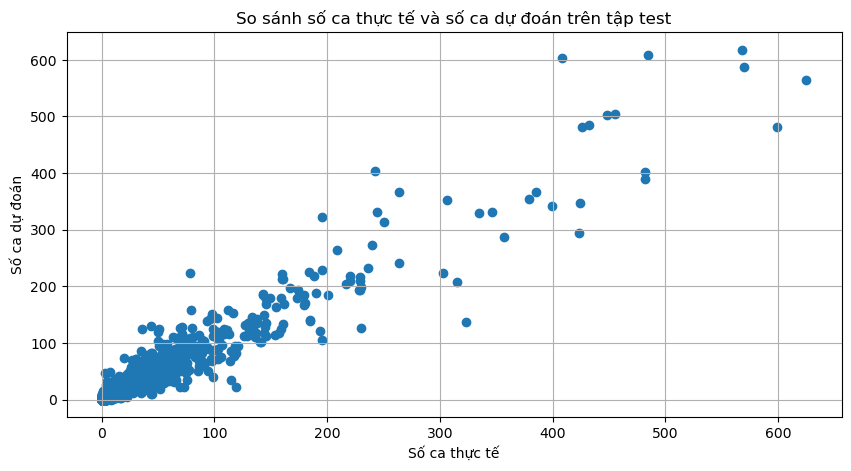

In [19]:
# cell 13
# Xem kết quả đánh giá model trên tập test

display(test_result[[
    "period",
    "disease_target",
    "age_group",
    "actual_cases",
    "predicted_cases"
]].head(30))

plt.figure(figsize=(10, 5))
plt.scatter(test_result["actual_cases"], test_result["predicted_cases"])
plt.xlabel("Số ca thực tế")
plt.ylabel("Số ca dự đoán")
plt.title("So sánh số ca thực tế và số ca dự đoán trên tập test")
plt.grid(True)
plt.show()

In [20]:
# cell 14
# Xác định tháng đã chốt và các tháng cần dự đoán

def get_last_completed_period(predict_monthly, last_completed_period="auto"):
    if last_completed_period == "auto":
        return str(pd.Period(predict_monthly["period"].max(), freq="M"))

    return str(pd.Period(last_completed_period, freq="M"))


def get_forecast_periods(last_completed_period, forecast_horizon=1):
    last_p = pd.Period(last_completed_period, freq="M")

    forecast_periods = [
        str(last_p + i) for i in range(1, forecast_horizon + 1)
    ]

    return forecast_periods


LAST_COMPLETED_PERIOD_RESOLVED = get_last_completed_period(
    predict_monthly,
    LAST_COMPLETED_PERIOD
)

FORECAST_PERIODS = get_forecast_periods(
    LAST_COMPLETED_PERIOD_RESOLVED,
    FORECAST_HORIZON
)

print("Tháng dữ liệu đã chốt:", LAST_COMPLETED_PERIOD_RESOLVED)
print("Các tháng sẽ dự đoán:", FORECAST_PERIODS)

Tháng dữ liệu đã chốt: 2026-05
Các tháng sẽ dự đoán: ['2026-06']


In [21]:
# cell 15
# Hàm tạo input dự đoán cho một tháng cụ thể
# Dùng 5 tháng trước tháng cần dự đoán.

def build_prediction_input_for_one_month(history_monthly, forecast_period, train_combinations):
    forecast_p = pd.Period(forecast_period, freq="M")

    needed_periods = [
        str(forecast_p - 5),
        str(forecast_p - 4),
        str(forecast_p - 3),
        str(forecast_p - 2),
        str(forecast_p - 1)
    ]

    start_period = needed_periods[0]
    end_period = needed_periods[-1]

    history_full = complete_monthly_grid(
        history_monthly,
        all_combinations=train_combinations,
        start_period=start_period,
        end_period=end_period
    )

    rows = []

    for _, combo in train_combinations.iterrows():
        disease_target = combo["disease_target"]
        age_group = combo["age_group"]

        temp = history_full[
            (history_full["disease_target"] == disease_target) &
            (history_full["age_group"] == age_group)
        ].copy()

        def get_cases(period):
            value = temp.loc[temp["period"] == period, "case_count"]

            if value.empty:
                return 0

            return int(value.iloc[0])

        lag_1 = get_cases(str(forecast_p - 1))
        lag_2 = get_cases(str(forecast_p - 2))
        lag_3 = get_cases(str(forecast_p - 3))
        lag_4 = get_cases(str(forecast_p - 4))
        lag_5 = get_cases(str(forecast_p - 5))

        rolling_3 = np.mean([lag_1, lag_2, lag_3])
        rolling_5 = np.mean([lag_1, lag_2, lag_3, lag_4, lag_5])
        change_1 = lag_1 - lag_2

        row = {
            "disease_target": disease_target,
            "age_group": age_group,
            "target_year": forecast_p.year,
            "target_month_num": forecast_p.month,
            "target_season": month_to_season_vn(forecast_p.month),
            "target_month_sin": np.sin(2 * np.pi * forecast_p.month / 12),
            "target_month_cos": np.cos(2 * np.pi * forecast_p.month / 12),
            "lag_1": lag_1,
            "lag_2": lag_2,
            "lag_3": lag_3,
            "lag_4": lag_4,
            "lag_5": lag_5,
            "rolling_3": rolling_3,
            "rolling_5": rolling_5,
            "change_1": change_1,
            "last_completed_period": str(forecast_p - 1),
            "forecast_period": str(forecast_p),
            "previous_cases": lag_1
        }

        rows.append(row)

    predict_input = pd.DataFrame(rows)

    return predict_input

In [22]:
# cell 16
# Hàm phân loại xu hướng và mức cảnh báo

def classify_trend_and_risk(previous_cases, predicted_cases, rolling_3):
    previous_cases = float(previous_cases)
    predicted_cases = float(predicted_cases)
    rolling_3 = float(rolling_3) if not pd.isna(rolling_3) else 0

    if previous_cases > 0:
        change_percent = ((predicted_cases - previous_cases) / previous_cases) * 100
    else:
        change_percent = np.nan

    # Xu hướng
    if previous_cases == 0 and predicted_cases > 0:
        trend = "Tăng từ 0 ca"
    elif pd.isna(change_percent):
        trend = "Không đủ dữ liệu"
    elif change_percent >= 30:
        trend = "Tăng mạnh"
    elif change_percent >= 10:
        trend = "Tăng"
    elif change_percent <= -30:
        trend = "Giảm mạnh"
    elif change_percent <= -10:
        trend = "Giảm"
    else:
        trend = "Ổn định"

    # Mức cảnh báo đơn giản
    if pd.isna(change_percent):
        risk_level = "Trung bình" if predicted_cases > 0 else "Thấp"
    elif change_percent >= 30 and predicted_cases >= 5:
        risk_level = "Cao"
    elif change_percent >= 10 and predicted_cases >= 5:
        risk_level = "Trung bình"
    elif predicted_cases >= max(rolling_3 * 1.5, 10):
        risk_level = "Cao"
    else:
        risk_level = "Thấp"

    return trend, risk_level, change_percent

In [23]:
# cell 17
# Dự đoán một hoặc nhiều tháng tới
# Nếu FORECAST_HORIZON = 1: dự đoán 1 tháng tới.
# Nếu FORECAST_HORIZON = 3: dự đoán 3 tháng tới theo kiểu cuốn chiếu.

loaded_model = joblib.load(MODEL_DIR / "seasonal_disease_forecast_model.pkl")

# history_monthly ban đầu là dữ liệu hiện tại đã import, ví dụ 01/2026-05/2026
history_monthly_for_forecast = predict_monthly.copy()

all_forecast_results = []
all_predict_inputs = []

for fp in FORECAST_PERIODS:
    print("\n==============================")
    print("Đang dự đoán tháng:", fp)
    print("==============================")

    predict_input = build_prediction_input_for_one_month(
        history_monthly=history_monthly_for_forecast,
        forecast_period=fp,
        train_combinations=train_combinations
    )

    X_forecast = predict_input[feature_cols]

    predicted = loaded_model.predict(X_forecast)
    predicted = np.clip(predicted, 0, None)

    one_result = predict_input.copy()
    one_result["predicted_cases"] = np.round(predicted).astype(int)

    trends = one_result.apply(
        lambda row: classify_trend_and_risk(
            row["previous_cases"],
            row["predicted_cases"],
            row["rolling_3"]
        ),
        axis=1
    )

    one_result["trend"] = [x[0] for x in trends]
    one_result["risk_level"] = [x[1] for x in trends]
    one_result["change_percent"] = [x[2] for x in trends]
    one_result["change_percent"] = one_result["change_percent"].round(2)

    all_forecast_results.append(one_result)
    all_predict_inputs.append(predict_input)

    # Nếu dự đoán nhiều tháng, đưa kết quả dự đoán tháng này vào history để dự đoán tháng tiếp theo.
    predicted_monthly = one_result[[
        "forecast_period",
        "disease_target",
        "age_group",
        "predicted_cases"
    ]].copy()

    predicted_monthly = predicted_monthly.rename(columns={
        "forecast_period": "period",
        "predicted_cases": "case_count"
    })

    predicted_monthly["year"] = pd.PeriodIndex(predicted_monthly["period"], freq="M").year
    predicted_monthly["month_num"] = pd.PeriodIndex(predicted_monthly["period"], freq="M").month
    predicted_monthly["season"] = predicted_monthly["month_num"].apply(month_to_season_vn)

    history_monthly_for_forecast = pd.concat([
        history_monthly_for_forecast,
        predicted_monthly[["period", "year", "month_num", "season", "disease_target", "age_group", "case_count"]]
    ], ignore_index=True)

predict_input_all = pd.concat(all_predict_inputs, ignore_index=True)
forecast_result = pd.concat(all_forecast_results, ignore_index=True)

risk_order = {
    "Cao": 3,
    "Trung bình": 2,
    "Thấp": 1
}

forecast_result["risk_rank"] = forecast_result["risk_level"].map(risk_order).fillna(0)

forecast_result = forecast_result.sort_values(
    ["forecast_period", "risk_rank", "predicted_cases"],
    ascending=[True, False, False]
).drop(columns=["risk_rank"])

print("Dự đoán hoàn tất.")

display(forecast_result[[
    "forecast_period",
    "disease_target",
    "age_group",
    "previous_cases",
    "predicted_cases",
    "change_percent",
    "trend",
    "risk_level"
]].head(100))


Đang dự đoán tháng: 2026-06
Dự đoán hoàn tất.


,forecast_period,disease_target,age_group,previous_cases,predicted_cases,change_percent,trend,risk_level
247,2026-06,Các bệnh viêm phổi - Pneumonia,1-5 tuổi,10,16,60.00,Tăng mạnh,Cao
873,2026-06,Viêm phế quản và viêm tiểu phế quản cấp - Acut...,Dưới 1 tuổi,10,16,60.00,Tăng mạnh,Cao
250,2026-06,Các bệnh viêm phổi - Pneumonia,Dưới 1 tuổi,11,15,36.36,Tăng mạnh,Cao
821,2026-06,Viêm cấp đường hô hấp trên khác - Other acute ...,6-10 tuổi,8,13,62.50,Tăng mạnh,Cao
847,2026-06,Viêm họng và viêm amidan cấp - Acute pharyngit...,6-10 tuổi,6,12,100.00,Tăng mạnh,Cao
...,...,...,...,...,...,...,...,...
716,2026-06,U da lành - Benign neoplasm of skin,1-5 tuổi,0,1,NaN,Tăng từ 0 ca,Trung bình
717,2026-06,U da lành - Benign neoplasm of skin,11-15 tuổi,0,1,NaN,Tăng từ 0 ca,Trung bình
718,2026-06,U da lành - Benign neoplasm of skin,6-10 tuổi,0,1,NaN,Tăng từ 0 ca,Trung bình
719,2026-06,U da lành - Benign neoplasm of skin,Dưới 1 tuổi,0,1,NaN,Tăng từ 0 ca,Trung bình


In [24]:
# cell 18
# Lưu kết quả dự báo ra file CSV để backend/database dùng sau này

forecast_suffix = "_".join(FORECAST_PERIODS)
forecast_csv_path = RESULT_DIR / f"forecast_results_{forecast_suffix}.csv"

forecast_result.to_csv(forecast_csv_path, index=False, encoding="utf-8-sig")

print("Đã lưu kết quả dự báo tại:", forecast_csv_path)

Đã lưu kết quả dự báo tại: results\forecast_results_2026-06.csv


In [25]:
# cell 19
# Lưu bảng thống kê tháng để dùng cho dashboard nhân viên y tế

train_monthly_path = RESULT_DIR / "train_monthly_statistics.csv"
predict_monthly_path = RESULT_DIR / "predict_monthly_statistics.csv"

train_monthly_full.to_csv(train_monthly_path, index=False, encoding="utf-8-sig")
predict_monthly.to_csv(predict_monthly_path, index=False, encoding="utf-8-sig")

print("Đã lưu thống kê lịch sử tại:", train_monthly_path)
print("Đã lưu thống kê dữ liệu hiện tại tại:", predict_monthly_path)

Đã lưu thống kê lịch sử tại: results\train_monthly_statistics.csv
Đã lưu thống kê dữ liệu hiện tại tại: results\predict_monthly_statistics.csv


In [26]:
# cell 20
# Test xem dự báo của một nhóm bệnh cụ thể

def show_forecast_for_disease(keyword):
    temp = forecast_result[
        forecast_result["disease_target"].str.contains(keyword, case=False, na=False)
    ].copy()

    if temp.empty:
        print(f"Không tìm thấy bệnh/nhóm bệnh chứa từ khóa: {keyword}")
        return

    display(temp[[
        "forecast_period",
        "disease_target",
        "age_group",
        "previous_cases",
        "predicted_cases",
        "change_percent",
        "trend",
        "risk_level"
    ]])


# Ví dụ:
show_forecast_for_disease("hô hấp")

,forecast_period,disease_target,age_group,previous_cases,predicted_cases,change_percent,trend,risk_level
821,2026-06,Viêm cấp đường hô hấp trên khác - Other acute ...,6-10 tuổi,8,13,62.50,Tăng mạnh,Cao
819,2026-06,Viêm cấp đường hô hấp trên khác - Other acute ...,1-5 tuổi,18,21,16.67,Tăng,Trung bình
820,2026-06,Viêm cấp đường hô hấp trên khác - Other acute ...,11-15 tuổi,0,1,NaN,Tăng từ 0 ca,Trung bình
822,2026-06,Viêm cấp đường hô hấp trên khác - Other acute ...,Dưới 1 tuổi,2,3,50.00,Tăng mạnh,Thấp
63,2026-06,Bệnh khác của bộ máy hô hấp - Other diseases o...,1-5 tuổi,0,0,NaN,Không đủ dữ liệu,Thấp
64,2026-06,Bệnh khác của bộ máy hô hấp - Other diseases o...,11-15 tuổi,0,0,NaN,Không đủ dữ liệu,Thấp
65,2026-06,Bệnh khác của bộ máy hô hấp - Other diseases o...,6-10 tuổi,0,0,NaN,Không đủ dữ liệu,Thấp
66,2026-06,Bệnh khác của bộ máy hô hấp - Other diseases o...,Dưới 1 tuổi,0,0,NaN,Không đủ dữ liệu,Thấp
67,2026-06,Bệnh khác của bộ máy hô hấp - Other diseases o...,Trên 15 tuổi,0,0,NaN,Không đủ dữ liệu,Thấp
143,2026-06,Bệnh khác đường hô hấp trên - Other diseases o...,1-5 tuổi,0,0,NaN,Không đủ dữ liệu,Thấp


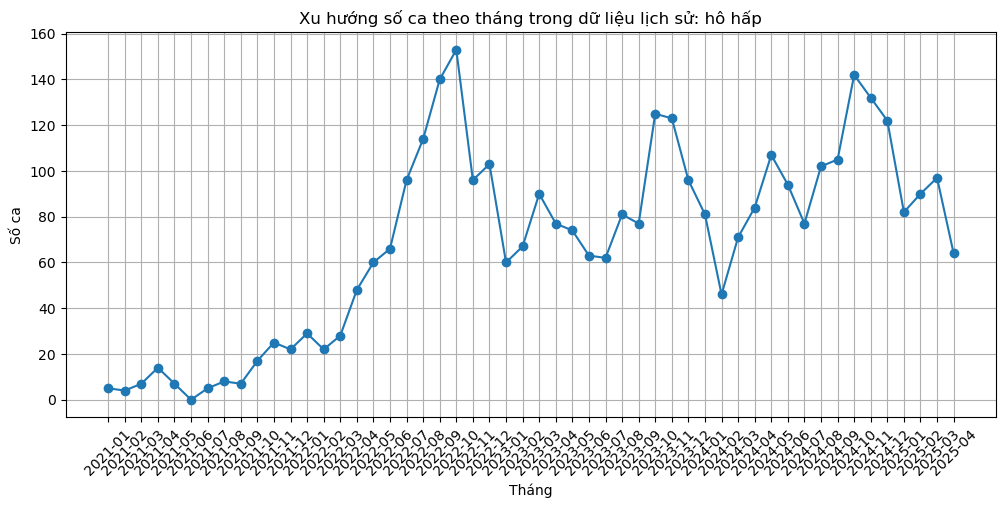

In [27]:
# cell 21
# Vẽ biểu đồ lịch sử của một nhóm bệnh trong dữ liệu train

def plot_disease_history(keyword, age_group=None):
    temp = train_monthly_full[
        train_monthly_full["disease_target"].str.contains(keyword, case=False, na=False)
    ].copy()

    if age_group is not None:
        temp = temp[temp["age_group"] == age_group]

    if temp.empty:
        print(f"Không tìm thấy dữ liệu cho từ khóa: {keyword}")
        return

    chart_data = (
        temp.groupby("period")["case_count"]
            .sum()
            .reset_index()
            .sort_values("period")
    )

    plt.figure(figsize=(12, 5))
    plt.plot(chart_data["period"], chart_data["case_count"], marker="o")
    plt.xticks(rotation=45)
    plt.xlabel("Tháng")
    plt.ylabel("Số ca")
    plt.title(f"Xu hướng số ca theo tháng trong dữ liệu lịch sử: {keyword}")
    plt.grid(True)
    plt.show()


# Ví dụ:
plot_disease_history("hô hấp")

In [28]:
# cell 22
# Tóm tắt toàn bộ luồng AI để kiểm tra

print("===== TÓM TẮT LUỒNG AI =====")

print("\n1. FILE TRAIN LỊCH SỬ")
print("File:", TRAIN_DATA_PATH)
print("Từ tháng:", train_df["period"].min())
print("Đến tháng:", train_df["period"].max())
print("Số dòng bệnh nhân train:", len(train_df))
print("Số dòng train_data dùng cho model:", len(train_data))

print("\n2. FILE DỮ LIỆU HIỆN TẠI ĐỂ DỰ ĐOÁN")
print("File:", PREDICT_DATA_PATH)
print("Từ tháng:", predict_df["period"].min())
print("Đến tháng:", predict_df["period"].max())
print("Số dòng bệnh nhân predict:", len(predict_df))
print("Tháng dữ liệu đã chốt:", LAST_COMPLETED_PERIOD_RESOLVED)

print("\n3. CÁC THÁNG CẦN DỰ ĐOÁN")
print(FORECAST_PERIODS)

print("\n4. MODEL")
print("Model đã lưu tại:", model_path)

print("\n5. KẾT QUẢ DỰ BÁO")
print("File kết quả:", forecast_csv_path)

print("\nHiểu đơn giản:")
print("- Model học từ dữ liệu lịch sử.")
print("- File hiện tại chỉ dùng làm input dự đoán.")
print("- Kết quả là số ca dự đoán, xu hướng và mức cảnh báo cho các tháng:", FORECAST_PERIODS)

===== TÓM TẮT LUỒNG AI =====

1. FILE TRAIN LỊCH SỬ
File: train_history.xlsx
Từ tháng: 2021-01
Đến tháng: 2025-04
Số dòng bệnh nhân train: 257771
Số dòng train_data dùng cho model: 47736

2. FILE DỮ LIỆU HIỆN TẠI ĐỂ DỰ ĐOÁN
File: predict_current.xlsx
Từ tháng: 2022-01
Đến tháng: 2026-05
Số dòng bệnh nhân predict: 16332
Tháng dữ liệu đã chốt: 2026-05

3. CÁC THÁNG CẦN DỰ ĐOÁN
['2026-06']

4. MODEL
Model đã lưu tại: models\seasonal_disease_forecast_model.pkl

5. KẾT QUẢ DỰ BÁO
File kết quả: results\forecast_results_2026-06.csv

Hiểu đơn giản:
- Model học từ dữ liệu lịch sử.
- File hiện tại chỉ dùng làm input dự đoán.
- Kết quả là số ca dự đoán, xu hướng và mức cảnh báo cho các tháng: ['2026-06']


In [29]:
# So sánh model với baseline đơn giản: dự đoán bằng lag_1

baseline_pred = df_test["lag_1"].values
actual = y_test.values

baseline_mae = mean_absolute_error(actual, baseline_pred)
baseline_rmse = math.sqrt(mean_squared_error(actual, baseline_pred))
baseline_r2 = r2_score(actual, baseline_pred) if len(actual) > 1 else np.nan

print("===== BASELINE: DỰ ĐOÁN BẰNG THÁNG TRƯỚC =====")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R2:", round(baseline_r2, 4))

print("\n===== RANDOM FOREST =====")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

===== BASELINE: DỰ ĐOÁN BẰNG THÁNG TRƯỚC =====
MAE: 2.29
RMSE: 7.97
R2: 0.9194

===== RANDOM FOREST =====
MAE: 2.21
RMSE: 7.68
R2: 0.9251


In [30]:
# Xem những dòng model dự đoán lệch nhiều nhất

test_result["abs_error"] = (test_result["actual_cases"] - test_result["predicted_cases"]).abs()

display(
    test_result[[
        "period",
        "disease_target",
        "age_group",
        "actual_cases",
        "predicted_cases",
        "abs_error"
    ]]
    .sort_values("abs_error", ascending=False)
    .head(30)
)

,period,disease_target,age_group,actual_cases,predicted_cases,abs_error
13047,2024-12,Các bệnh viêm phổi - Pneumonia,Dưới 1 tuổi,408,603,195
8153,2024-06,Bệnh mạn tính của amidan và của VA - Chronic d...,6-10 tuổi,323,137,186
12895,2025-04,Các bệnh viêm phổi - Pneumonia,1-5 tuổi,242,403,161
8102,2024-07,Bệnh mạn tính của amidan và của VA - Chronic d...,11-15 tuổi,78,224,146
13051,2025-04,Các bệnh viêm phổi - Pneumonia,Dưới 1 tuổi,195,323,128
12894,2025-03,Các bệnh viêm phổi - Pneumonia,1-5 tuổi,423,295,128
12891,2024-12,Các bệnh viêm phổi - Pneumonia,1-5 tuổi,485,608,123
12889,2024-10,Các bệnh viêm phổi - Pneumonia,1-5 tuổi,599,482,117
43985,2024-10,Viêm họng và viêm amidan cấp - Acute pharyngit...,1-5 tuổi,315,207,108
48461,2025-02,"Ỉa chảy, viêm dạy dày, ruột non có nguồn gốc n...",1-5 tuổi,230,126,104


In [31]:
# Đánh giá theo từng nhóm bệnh

group_eval = []

for disease, temp in test_result.groupby("disease_target"):
    if len(temp) < 5:
        continue

    actual = temp["actual_cases"]
    pred = temp["predicted_cases"]

    group_eval.append({
        "disease_target": disease,
        "rows": len(temp),
        "total_actual_cases": actual.sum(),
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": math.sqrt(mean_squared_error(actual, pred)),
        "R2": r2_score(actual, pred) if len(actual) > 1 else np.nan
    })

group_eval_df = pd.DataFrame(group_eval)

display(
    group_eval_df
    .sort_values("total_actual_cases", ascending=False)
    .head(30)
)

,disease_target,rows,total_actual_cases,MAE,RMSE,R2
55,Các bệnh viêm phổi - Pneumonia,66,10375,29.121212,52.067846,0.933851
221,Viêm phế quản và viêm tiểu phế quản cấp - Acut...,55,4089,16.781818,29.145092,0.900730
215,Viêm họng và viêm amidan cấp - Acute pharyngit...,55,3618,14.309091,24.644011,0.904883
76,Dị tật bẩm sinh khác của bộ máy sinh dục tiết ...,55,3494,14.600000,23.878861,0.877068
235,"Ỉa chảy, viêm dạy dày, ruột non có nguồn gốc n...",55,3491,15.127273,23.120239,0.877644
54,Các bệnh nhiễm khuẩn ruột khác - Other intesti...,66,3226,11.439394,19.047389,0.888060
5,Bệnh bạch cầu - Leukaemia,55,2240,7.636364,12.219210,0.889145
33,Bệnh mạn tính của amidan và của VA - Chronic d...,55,1884,19.727273,41.777549,0.522590
61,"Các triệu chứng, dấu hiệu và kết quả bất thườn...",66,1646,5.575758,10.013627,0.857179
87,Hen - Asthma,55,1635,10.036364,16.652600,0.857350


In [32]:
# Kiểm tra 2021-01 có được dùng làm lag_1 cho 2021-02 không

sample_group = train_feature_all[["disease_target", "age_group"]].drop_duplicates().iloc[0]

sample = train_feature_all[
    (train_feature_all["disease_target"] == sample_group["disease_target"]) &
    (train_feature_all["age_group"] == sample_group["age_group"])
].copy()

display(sample[[
    "period",
    "disease_target",
    "age_group",
    "case_count",
    "lag_1",
    "target_cases"
]].head(5))

,period,disease_target,age_group,case_count,lag_1,target_cases
0,2021-01,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,NaN,0
1,2021-02,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0.0,0
2,2021-03,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0.0,0
3,2021-04,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0.0,0
4,2021-05,Biến dạng các chi mắc phải - Accquired deformi...,1-5 tuổi,0,0.0,0


# cell test số lượng cây Random Forest

import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import pandas as pd
import numpy as np

tree_list = [100, 300, 400, 500, 600]

rf_compare_results = []

for n_trees in tree_list:
    print(f"\n===== TRAIN RANDOM FOREST {n_trees} CÂY =====")
    
    start_time = time.time()
    
    rf = RandomForestRegressor(
        n_estimators=n_trees,
        random_state=42,
        min_samples_leaf=2,
        n_jobs=-1
    )
    
    rf.fit(X_train_processed, y_train)
    
    pred = rf.predict(X_test_processed)
    pred = np.clip(pred, 0, None)
    
    train_time = time.time() - start_time
    
    mae_temp = mean_absolute_error(y_test, pred)
    rmse_temp = math.sqrt(mean_squared_error(y_test, pred))
    r2_temp = r2_score(y_test, pred) if len(y_test) > 1 else np.nan
    
    rf_compare_results.append({
        "n_estimators": n_trees,
        "MAE": mae_temp,
        "RMSE": rmse_temp,
        "R2": r2_temp,
        "train_time_seconds": train_time
    })
    
    print("MAE:", round(mae_temp, 4))
    print("RMSE:", round(rmse_temp, 4))
    print("R2:", round(r2_temp, 4))
    print("Thời gian train:", round(train_time, 2), "giây")

rf_compare_df = pd.DataFrame(rf_compare_results)

display(
    rf_compare_df.sort_values("MAE")
)

Note:
Dữ liệu được train từ 2/2021 đến 5/2024, còn test thì 6/2024 đến 4/2025